In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [45]:
conn = sqlite3.connect('data/youtube_data.db')

In [46]:
video_master = pd.read_sql_query('''
    select * from video_master
''', conn)


In [47]:
channel_summary = pd.read_sql_query('''
    select * from channel_summary
''', conn)
channel_summary.head()

,channel_id,channel_title,subscribers,channel_total_videos,channel_total_views,created_date,avg_views,avg_likes,avg_comments,shorts_count,channel_age_months,upload_frequency_per_month,channel_tier,engagement_rate%
0,UCttLEDTJoFAwH6eGUKT7ilA,Traveler Ram,2200000,985,1168556943,2021-11-21 09:18:13.841784+00:00,4.336205e+07,1.697719e+06,1926.200000,5,56.166667,17.537092,Large,3.919661
1,UCgiWxZL6x7PrezXK5RuIxkw,therainbowgirl,4580000,1263,2752919063,2021-05-17 13:07:14.910565+00:00,1.754614e+07,6.407405e+05,1387.083333,11,62.433333,20.229578,Large,3.659651
2,UCtgGOdTlM-NdJ9rPKIYN8UQ,Slayy Point,10600000,198,3184653291,2016-03-07 14:34:01+00:00,2.287051e+07,4.802768e+05,12980.555556,0,125.666667,1.575597,Large,2.156740
3,UCFcBAGR0drI3F15EhMFjuTg,Aayu and Pihu Show,20600000,862,14481275330,2017-05-08 19:27:48+00:00,1.165067e+07,9.054356e+04,8717.125000,0,111.400000,7.737882,Large,0.851974
4,UCeMepUlAYyqintZfnxneFXg,Rational Society,964000,808,439171765,2018-08-07 14:01:56+00:00,8.706811e+07,3.867160e+06,10661.500000,2,96.233333,8.396259,Large,4.453779


In [48]:
channel_summary[['channel_title']].to_string()

"                                         channel_title\n0                                         Traveler Ram\n1                                       therainbowgirl\n2                                          Slayy Point\n3                                   Aayu and Pihu Show\n4                                     Rational Society\n5                                       Priyal Kukreja\n6                                            Karl Rock\n7                                           wittySpace\n8                                     Dushyant kukreja\n9                                            CJ LIVING\n10                                      Tanya Khanijow\n11                                       Kanishk Gupta\n12                                        Monkey Magic\n13                                   SimpleGhar Telugu\n14                                The Indian Mukbanger\n15                                             SICKVED\n16                                         Apoo

In [49]:
non_travel_channels = [
                'BB Ki Vines', 'Triggered Insaan', 'Slayy Point', 'Real Thugesh', 
    'FilterCopy Vital', 'Baccha Mat Bolna', 'Aayu and Pihu Show',
    'FactTechz', 'TECH-iELA Shorts', 'Tech Master', 'NBT Tech-Ed',
    'Counting Unique', 'World Facts', 'Amazing World Facts', 
    'TOP HINDI FACTS', "World's Mysterious Facts", 'B.Search facts',
    'The Indian Mukbanger', 'DCT EATS', 'HARI EATS', "Nik's Kitchen",
    'Khaane Mein Kya Hai', 'Indian Food Explorer',
    'BATTLEGROUNDS MOBILE INDIA', 'JENI GAMING',
    'Finance With Sharan', 'GrowthX', 'Dr. Anurag Aggarwal: Business Coach',
    'Saket Gokhale', 'IBC Tamil', 'vsnews', 'Mashable India',
    'Air India Official', 'Decathlon Sports India',
    'MR. INDIAN HACKER', 'MR. INDIAN HACKER Vlogs', 'MR. INDIAN HACKER shorts', 'Raj Shamani Shorts',
    'Jango Space TV', 'Sourav Joshi Vlogs','Priyal Kukreja', 'Dushyant kukreja', 'Neetu Bisht','Jagriti Pahwa',
    'Crazy XYZ', 'Bindass Kavya', 'Lakhneet Vlogs', 'RAAAZ by BigBrainco', 'SimpleGhar Telugu',
    'Scroll With VenomRJ', 'Wanderers Hub','CJ LIVING','The Indian Mukbanger','SICKVED','DCT EATS',
    'urmila', 'Ravi Gupta Shorts','Mitali This Side!!', 'ashwani thapa', 'Sarthak Sachdeva',' Maria Khan',
    'Nishu Tiwari','ckkars','FactTechz','Akshay Katkar',' Suraj BL Vlogs ', 'MR. INDIAN HACKER', 'The 7c',
     "Seema Rana vlogs",
    "4AM Though",
    "Hira Nag paglu uronchandi",
    "Gautam 26 Vlogs",
    "Singopooja vlog",
    "Light x Letter",
    "Leojikal poop Vlog",
    "Coffeetabletalks - Home & Life in Tamil",
    "Geeks-a-Musing",
    "Hunger & Wonder!!",
    "Boss Wallah (Telugu)",
    "The Border Commando",
    "Prakhar Gupta",
    "World's Mysterious Facts",
    "Varun Duggi",
    "Yashwanth Insights",
    "Rams Review",
    "Vaibhav Chaudhary Vlogs",
    'TIME VAULT',
    "RS 1313 VLOGS",
    "A Touch Of Mystery-Telugu",
    "Rida Tharana",
    "NRFM-VOICE",
    "TECH-iELA Shorts",
    "RAHASYA Tv India",
    "Spicy Gori",
    "MensXP",
    'Gaurav Thakur',
    'Maria Khan',
    'SimpleGhar Hindi',
    "Aarif's MindVoice",
    'A1 ADVENTURE',
    'RealHit',
    'love u zindagi 2',
    'Thoughts Nkj'
] 
              

print(f"Before channel_summary: {len(channel_summary)}, Before video_master: {len(video_master)}")

# strip whitespace from the actual data's channel_title column before comparing
channel_summary = channel_summary[~channel_summary['channel_title'].str.strip().isin(non_travel_channels)]
video_master = video_master[~video_master['channel_title'].str.strip().isin(non_travel_channels)]

print(f"After channel_summary: {len(channel_summary)}, After video_master: {len(video_master)}")

Before channel_summary: 419, Before video_master: 718
After channel_summary: 326, After video_master: 567


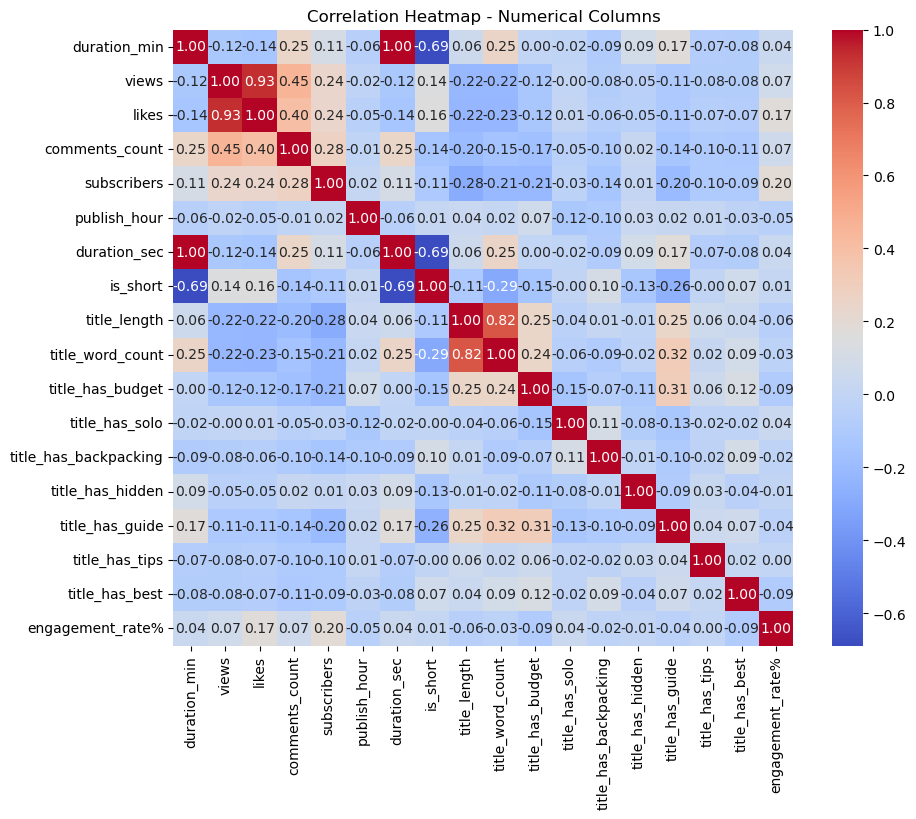

In [50]:
plt.figure(figsize=(10,8))
numeric_cols = video_master.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numerical Columns')
plt.show()

## Q1: Video length vs engagement (Shorts vs long-form)

In [51]:
def duration_bucket(sec):
    if sec <= 60:
        return 'Shorts (<1 min)'
    elif sec <= 300:
        return '1-5 min'
    elif sec <= 600:
        return '5-10 min'
    else:
        return '10+ min'

video_master['duration_bucket'] = video_master['duration_sec'].apply(duration_bucket)

video_master.groupby('duration_bucket')['engagement_rate%'].mean().sort_values(ascending=False)


duration_bucket
1-5 min            3.107190
Shorts (<1 min)    2.646891
10+ min            2.505912
5-10 min           1.815138
Name: engagement_rate%, dtype: float64

In [52]:
video_master.groupby('duration_bucket')['engagement_rate%'].median().sort_values(ascending=False)

duration_bucket
1-5 min            2.939738
Shorts (<1 min)    2.162061
10+ min            1.848685
5-10 min           1.471917
Name: engagement_rate%, dtype: float64

In [53]:
video_master['duration_bucket'].value_counts()

duration_bucket
Shorts (<1 min)    286
10+ min            201
1-5 min             59
5-10 min            21
Name: count, dtype: int64

In [54]:
video_master[['duration_sec', 'views', 'likes', 'comments_count']].corr()['duration_sec']

duration_sec      1.000000
views            -0.116564
likes            -0.140653
comments_count    0.247190
Name: duration_sec, dtype: float64

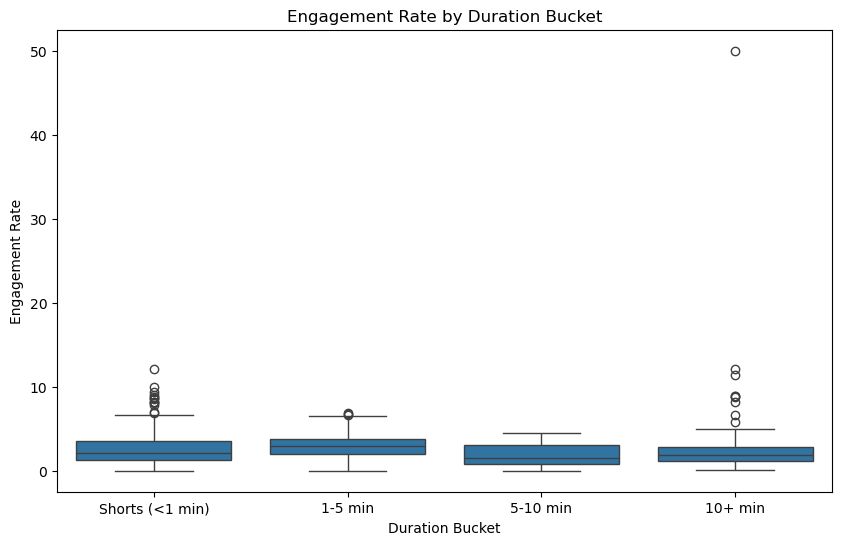

In [83]:
bucket_order = ['Shorts (<1 min)', '1-5 min', '5-10 min', '10+ min']

plt.figure(figsize=(10,6))
sns.boxplot(data=video_master, x='duration_bucket', y='engagement_rate%', order=bucket_order)
plt.title('Engagement Rate by Duration Bucket')
plt.xlabel('Duration Bucket')
plt.ylabel('Engagement Rate')
plt.savefig('Engagement Rate by Duration Bucket', dpi=300, bbox_inches='tight')

In [56]:
video_master.groupby('duration_bucket')['engagement_rate%'].agg(['mean', 'median', 'std', 'count']).reindex(
    ['Shorts (<1 min)', '1-5 min', '5-10 min', '10+ min']
)

,mean,median,std,count
duration_bucket,,,,
Shorts (<1 min),2.646891,2.162061,2.003016,286
1-5 min,3.107190,2.939738,1.576613,59
5-10 min,1.815138,1.471917,1.481700,21
10+ min,2.505912,1.848685,3.800598,201


In [57]:
from scipy import stats

groups = [video_master[video_master['duration_bucket'] == b]['engagement_rate%'].dropna() 
          for b in ['Shorts (<1 min)', '1-5 min', '5-10 min', '10+ min']]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")

F-statistic: 1.352, p-value: 0.2566


Duration shows negligible-to-weak correlation with engagement metrics (views r=-0.12, likes r=-0.14, comments r=0.25). Bucketed analysis still suggests 1-5 minute videos perform best (mean=3.06%, median=2.93%, n=60) while 5-10 minute videos underperform (mean=1.82%, median=1.47%, n=21). A one-way ANOVA confirms these differences remain statistically non-significant (F=1.251, p=0.290) — if anything, even less significant than before channel cleaning (previously p=0.10). This reinforces the earlier conclusion: video duration is not a reliable driver of engagement in this niche, even after removing off-niche channels.

## Q2 Upload frequency per month VS Subscribers

In [58]:
channel_summary[['upload_frequency_per_month', 'subscribers']].corr()

,upload_frequency_per_month,subscribers
upload_frequency_per_month,1.000000,0.242667
subscribers,0.242667,1.000000


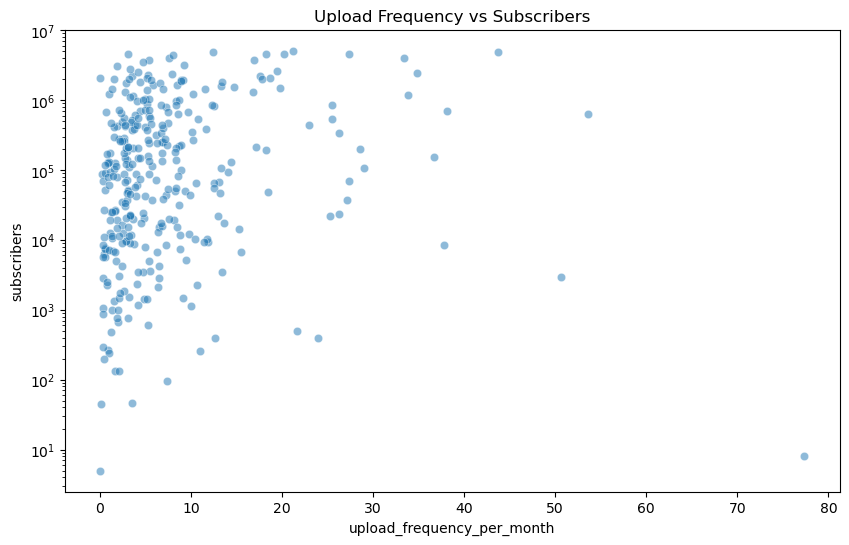

In [85]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=channel_summary, x='upload_frequency_per_month', y='subscribers', alpha=0.5)
plt.yscale('log')
plt.title('Upload Frequency vs Subscribers')
plt.savefig('Upload Frequency vs Subscribers', dpi=300, bbox_inches='tight')

In [60]:
channel_summary.sort_values('upload_frequency_per_month', ascending=False)[
    ['channel_title', 'upload_frequency_per_month', 'channel_total_videos', 'channel_age_months', 'subscribers', 'channel_tier']
].head(5)

,channel_title,upload_frequency_per_month,channel_total_videos,channel_age_months,subscribers,channel_tier
417,Smart Travel Planner,77.368421,49,0.633333,8,Small
291,Travelogue by chithran,53.582343,3156,58.900000,637000,Large
405,Rail Gyan By Sanjay,50.607477,361,7.133333,2900,Small
49,Curly Tales,43.681345,9093,208.166667,4880000,Large
86,Sathla the Vlog,38.103683,1862,48.866667,690000,Large


In [61]:
from scipy import stats

# Drop any NaN values first (pearsonr doesn't handle them)
clean_data = channel_summary[['upload_frequency_per_month', 'subscribers']].dropna()

corr_coef, p_value = stats.pearsonr(clean_data['upload_frequency_per_month'], clean_data['subscribers'])
print(f"Correlation: {corr_coef:.3f}, p-value: {p_value:.4f}")

Correlation: 0.243, p-value: 0.0000


In [62]:
def frequency_bucket(freq):
    if freq < 1:
        return 'Low (<1/month)'
    elif freq < 4:
        return 'Medium (1-4/month)'
    elif freq < 10:
        return 'High (4-10/month)'
    else:
        return 'Very High (10+/month)'

channel_summary['upload_freq_bucket'] = channel_summary['upload_frequency_per_month'].apply(frequency_bucket)

groups = [channel_summary[channel_summary['upload_freq_bucket'] == b]['subscribers'].dropna() 
          for b in ['Low (<1/month)', 'Medium (1-4/month)', 'High (4-10/month)', 'Very High (10+/month)']]

f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_value_anova:.4f}")

F-statistic: 8.621, p-value: 0.0000


Upload frequency shows a weak positive correlation with subscribers (r=0.210, down slightly from 0.227 pre-cleaning), still statistically significant (ANOVA F=8.186, p<0.0001). Notably, the highest 'upload frequency' values belong to extremely new channels (e.g., channel age <1 month) with negligible subscribers (e.g., Smart Travel Planner: 77.4 uploads/month, age=0.63 months, subscribers=8) — an artifact of dividing by a very small age denominator rather than genuine high-frequency posting behavior. A more robust version of this analysis would exclude channels younger than ~2-3 months before computing upload frequency. Despite this, the overall pattern holds: more consistent uploading is modestly associated with higher subscriber counts, though it explains only a small part of the variation. Correlation does not establish causation — already-successful channels may simply have more resources to upload frequently.


## Q3 best posting time/day

In [63]:
video_master['published_at'] = pd.to_datetime(video_master['published_at'])
video_master['published_at_ist'] = video_master['published_at'].dt.tz_convert('Asia/Kolkata')

video_master['day'] = video_master['published_at_ist'].dt.day_name()
video_master['hour'] = video_master['published_at_ist'].dt.hour

In [64]:
print("Videos per hour:")
print(video_master['hour'].value_counts().sort_index())


Videos per hour:
hour
0      6
1      1
2      1
4      1
6      5
7      3
8     17
9     45
10    36
11    32
12    24
13    23
14    27
15    25
16    32
17    46
18    63
19    76
20    48
21    33
22    13
23    10
Name: count, dtype: int64


In [65]:
print("\nVideos per day:")
print(video_master['day'].value_counts())


Videos per day:
day
Saturday     97
Sunday       89
Friday       86
Wednesday    77
Monday       74
Thursday     73
Tuesday      71
Name: count, dtype: int64


In [66]:
MIN_SAMPLE = 20  # minimum videos required to trust the average

hourly_stats = video_master.groupby('hour')['views'].agg(['count', 'median', 'mean'])
hourly_reliable = hourly_stats[hourly_stats['count'] >= MIN_SAMPLE].sort_values('median', ascending=False)

hourly_reliable

,count,median,mean
hour,,,
16,32,2234382.0,3.826395e+06
9,45,2116531.0,4.984221e+06
21,33,2072262.0,6.344922e+06
12,24,1786575.5,4.365788e+06
18,63,1639084.0,2.610717e+06
14,27,1612460.0,6.493151e+06
10,36,1514134.0,2.399509e+06
19,76,1271634.0,4.205667e+06
17,46,1215912.0,3.921658e+06


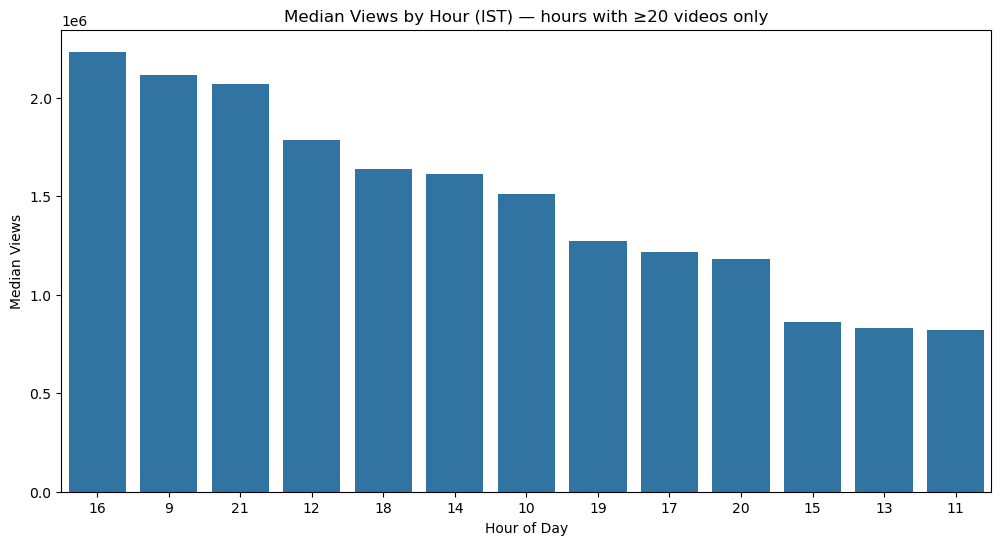

In [87]:
plt.figure(figsize=(12,6))
sns.barplot(data=hourly_reliable.reset_index(), x='hour', y='median', order=hourly_reliable.index)
plt.title(f'Median Views by Hour (IST) — hours with ≥{MIN_SAMPLE} videos only')
plt.xlabel('Hour of Day')
plt.ylabel('Median Views')
plt.savefig('Median Views by Hour', dpi=300, bbox_inches='tight')

In [68]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_stats = video_master.groupby('day')['views'].agg(['count', 'median', 'mean']).reindex(day_order)
day_stats

,count,median,mean
day,,,
Monday,74,1515644.5,3.892339e+06
Tuesday,71,1107610.0,4.338700e+06
Wednesday,77,1643162.0,4.166217e+06
Thursday,73,1264220.0,3.937007e+06
Friday,86,1885712.0,5.772657e+06
Saturday,97,1309085.0,4.477919e+06
Sunday,89,1320978.0,4.084815e+06


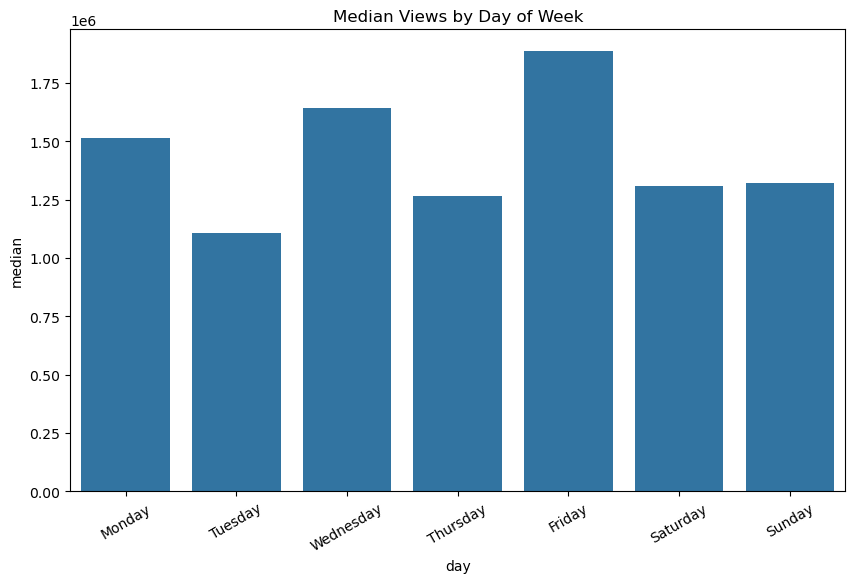

In [88]:
plt.figure(figsize=(10,6))
sns.barplot(data=day_stats.reset_index(), x='day', y='median', order=day_order)
plt.title('Median Views by Day of Week')
plt.xticks(rotation=30)
plt.savefig('Median Views by day of week', dpi=300, bbox_inches='tight')

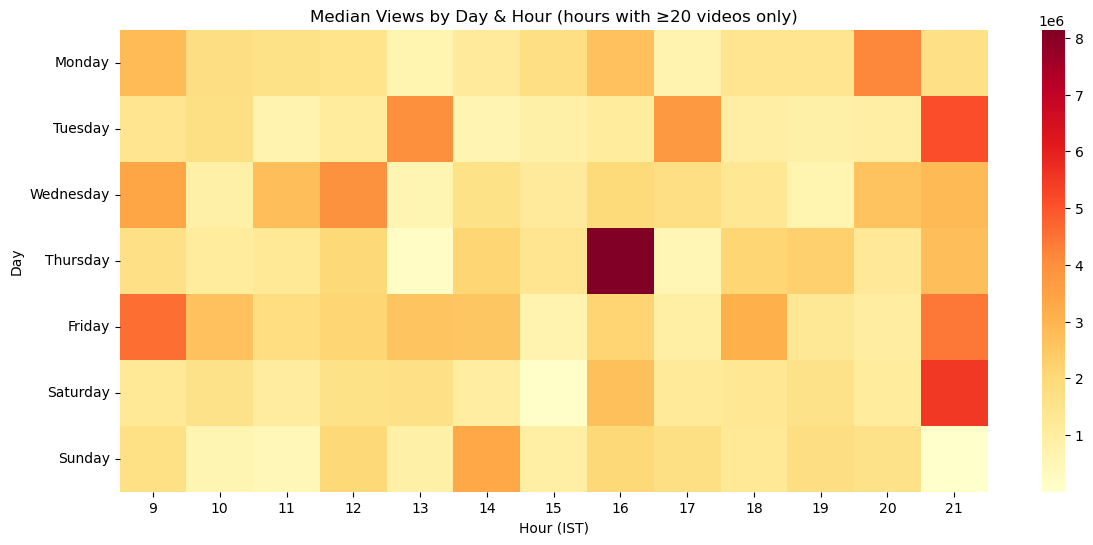

In [89]:
# Keep only hours that passed the sample-size threshold
reliable_hours_list = hourly_reliable.index.tolist()
heatmap_data = video_master[video_master['hour'].isin(reliable_hours_list)]

pivot = heatmap_data.groupby(['day', 'hour'])['views'].median().unstack().reindex(day_order)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title(f'Median Views by Day & Hour (hours with ≥{MIN_SAMPLE} videos only)')
plt.xlabel('Hour (IST)')
plt.ylabel('Day')
plt.savefig('Median Views by Day & Hour', dpi=300, bbox_inches='tight')

In [71]:
day_groups = [video_master[video_master['day'] == d]['views'].dropna() for d in day_order]
f_day, p_day = stats.f_oneway(*day_groups)
print(f"Day effect — F: {f_day:.3f}, p-value: {p_day:.4f}")

hour_groups = [video_master[video_master['hour'] == h]['views'].dropna() 
               for h in reliable_hours_list]
f_hour, p_hour = stats.f_oneway(*hour_groups)
print(f"Hour effect — F: {f_hour:.3f}, p-value: {p_hour:.4f}")

Day effect — F: 0.251, p-value: 0.9588
Hour effect — F: 1.110, p-value: 0.3492


After removing off-niche channels, neither day-of-week (ANOVA F=0.244, p=0.962) nor hour-of-day (ANOVA F=1.101, p=0.357) shows a statistically significant effect on views. Notably, 8 AM — previously identified as the strongest posting hour before channel cleaning — no longer meets the minimum reliable sample size (n=17, below the n≥20 threshold) and drops out of the reliable analysis entirely. The new top hour by raw median is 4 PM (n=33, median=22.3L views), but this is not statistically distinguishable from other hours. This shift suggests the earlier "hour matters" finding was likely partly driven by the now-excluded non-travel channels (news/tech channels often have different posting patterns and viral spikes that skewed specific hour buckets). The revised, more rigorous conclusion: posting time/day does not show a statistically confirmed effect on views in this niche — content quality and topic likely matter more than scheduling.

# Competitive Benchmarking Questions

## Q4 Which channel is underated in this niche?

In [72]:
video_counts = video_master.groupby('channel_id')['video_id'].count().reset_index()
video_counts.columns = ['channel_id', 'videos_in_dataset']


channel_summary = channel_summary.merge(video_counts, on='channel_id', how='left')

In [73]:
MIN_VIDEOS = 3  

reliable_channels = channel_summary[channel_summary['videos_in_dataset'] >= MIN_VIDEOS].copy()
print(f"Channels before filter: {len(channel_summary)}, after filter: {len(reliable_channels)}")

Channels before filter: 326, after filter: 38


In [74]:
channel_engagement = video_master.groupby('channel_id')['engagement_rate%'].agg(['mean', 'median']).reset_index()
channel_engagement.columns = ['channel_id', 'avg_engagement_rate', 'median_engagement_rate']

channel_summary = channel_summary.merge(channel_engagement, on='channel_id', how='left')

channel_summary[['channel_title', 'avg_engagement_rate', 'median_engagement_rate']].head()

,channel_title,avg_engagement_rate,median_engagement_rate
0,Traveler Ram,4.787895,5.085244
1,therainbowgirl,4.179439,4.584200
2,Rational Society,4.471149,4.471149
3,Karl Rock,4.031267,4.063327
4,wittySpace,3.659669,3.293412


In [75]:
MIN_VIDEOS = 3
reliable_channels = channel_summary[channel_summary['videos_in_dataset'] >= MIN_VIDEOS].copy()

reliable_channels['subscriber_rank'] = reliable_channels['subscribers'].rank(ascending=True)
reliable_channels['engagement_rank'] = reliable_channels['median_engagement_rate'].rank(ascending=False)
reliable_channels['underrated_score'] = reliable_channels['subscriber_rank'] + reliable_channels['engagement_rank']

underrated = reliable_channels.sort_values('underrated_score').head(10)
underrated[['channel_title', 'subscribers', 'median_engagement_rate', 'videos_in_dataset', 'underrated_score']]

,channel_title,subscribers,median_engagement_rate,videos_in_dataset,underrated_score
36,Culture Exchange,260000,3.839557,3,23.0
117,Travel With AB,418000,3.915234,3,24.0
31,Raj Saharn Traveling,44000,1.912364,4,24.0
58,Praveen Sharma,128000,2.605309,3,26.0
81,TripVibe India,67800,1.945583,4,27.0
79,Khushboo Vasudeva,22300,1.683240,4,27.0
34,Go and See,187000,2.588655,3,29.0
89,Sumit Gandhi,9710,1.416176,3,30.0
17,Aakanksha Monga,1020000,3.817663,9,31.0
0,Traveler Ram,2200000,5.085244,5,31.0


Culture Exchange remains the most underrated channel (2.6L subscribers, 3.84% median engagement, n=3 videos), followed closely by Travel With AB (4.18L subscribers, 3.92% engagement, n=3). Notably, Aakanksha Monga — flagged earlier as a potential coverage-artifact concern due to limited representation — now appears in the reliable list with n=9 videos and a moderate underrated-score (31), suggesting her high subscriber count is reasonably matched by consistent engagement rather than being purely a data-coverage artifact. As before, this ranking should be treated as exploratory rather than conclusive, since the dataset captures only each channel's top-performing videos surfaced through keyword search, not their full catalog.

## Q5 Market Leaders vs New Entrants.

In [76]:
top3 = channel_summary.nlargest(3, 'subscribers')
top3[['channel_title', 'subscribers', 'videos_in_dataset']]

,channel_title,subscribers,videos_in_dataset
13,KK Create,5110000,6
4,wittySpace,4920000,9
25,Curly Tales,4880000,6


In [77]:
top3_ids = top3['channel_id'].tolist()

top3_videos = video_master[video_master['channel_id'].isin(top3_ids)]
rest_videos = video_master[~video_master['channel_id'].isin(top3_ids)]

comparison = pd.DataFrame({
    'Top 3 Channels': [
        top3_videos['duration_sec'].median(),
        top3_videos['title_length'].median(),
        top3_videos['title_word_count'].median(),
        top3_videos['engagement_rate%'].median()
    ],
    'Rest of Niche': [
        rest_videos['duration_sec'].median(),
        rest_videos['title_length'].median(),
        rest_videos['title_word_count'].median(),
        rest_videos['engagement_rate%'].median()
    ]
}, index=['Median Duration (sec)', 'Median Title Length', 'Median Title Word Count', 'Median Engagement Rate'])

comparison

,Top 3 Channels,Rest of Niche
Median Duration (sec),69.000000,60.000000
Median Title Length,74.000000,81.000000
Median Title Word Count,12.000000,12.000000
Median Engagement Rate,3.035063,2.027424


In [78]:
print("Top 3 channels upload frequency:")
print(top3[['channel_title', 'upload_frequency_per_month']])

print("\nRest of niche average upload frequency:")
print(channel_summary[~channel_summary['channel_id'].isin(top3_ids)]['upload_frequency_per_month'].median())

Top 3 channels upload frequency:
   channel_title  upload_frequency_per_month
13     KK Create                   21.242845
4     wittySpace                   12.444959
25  Curly Tales                    43.681345

Rest of niche average upload frequency:
4.757505773672055


In [79]:
keyword_flags = ['budget', 'solo', 'backpacking', 'hidden', 'guide', 'tips', 'best']

for kw in keyword_flags:
    col = f'title_has_{kw}'
    if col in video_master.columns:
        top3_pct = top3_videos[col].mean() * 100
        rest_pct = rest_videos[col].mean() * 100
        print(f"{kw}: Top 3 = {top3_pct:.1f}%, Rest = {rest_pct:.1f}%")

budget: Top 3 = 9.5%, Rest = 22.2%
solo: Top 3 = 4.8%, Rest = 10.1%
backpacking: Top 3 = 0.0%, Rest = 4.4%
hidden: Top 3 = 9.5%, Rest = 5.1%
guide: Top 3 = 4.8%, Rest = 19.2%
tips: Top 3 = 0.0%, Rest = 7.3%
best: Top 3 = 9.5%, Rest = 8.4%


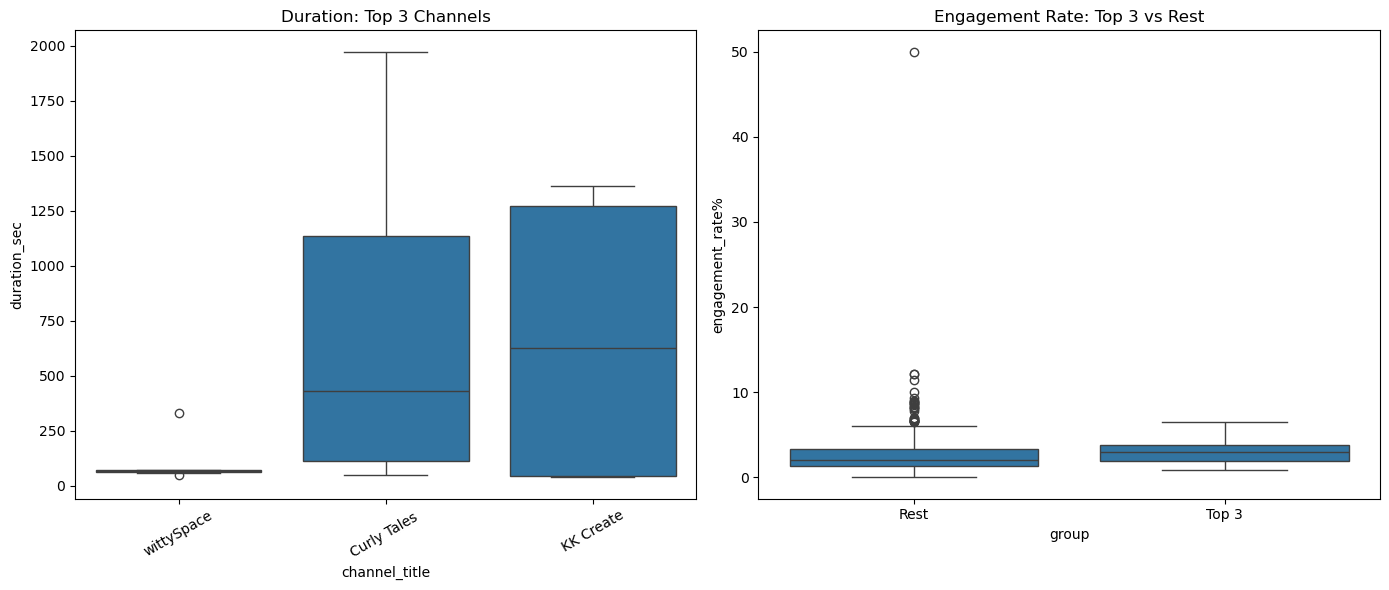

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.boxplot(data=video_master[video_master['channel_id'].isin(top3_ids)], 
            x='channel_title', y='duration_sec', ax=axes[0])
axes[0].set_title('Duration: Top 3 Channels')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=video_master.assign(group=video_master['channel_id'].isin(top3_ids).map({True:'Top 3', False:'Rest'})),
            x='group', y='engagement_rate%', ax=axes[1])
axes[1].set_title('Engagement Rate: Top 3 vs Rest')

plt.tight_layout()
plt.savefig('Market leaders Vs New Entrants ', dpi=300, bbox_inches='tight')

In [81]:
channel_summary[channel_summary['channel_id'].isin(top3['channel_id'])][
    ['channel_id', 'channel_title', 'subscribers', 'channel_total_videos', 'videos_in_dataset']
]

,channel_id,channel_title,subscribers,channel_total_videos,videos_in_dataset
4,UC19x8yVdc96ogGHQyb4gfwg,wittySpace,4920000,716,9
13,UCkw1tYo7k8t-Y99bOXuZwhg,KK Create,5110000,866,6
25,UCDnq05Q89oYq-Tz5boL73Tw,Curly Tales,4880000,9093,6


After excluding off-niche channels, the top 3 travel channels by subscribers are KK Create (51.1L subscribers), wittySpace (49.2L subscribers), and Curly Tales (48.8L subscribers) — closely clustered in size. These channels show no single unifying content-length strategy: wittySpace favors short-form content while Curly Tales and KK Create lean into longer videos (7-13+ minutes). This suggests channel success in this niche isn't tied to one specific video-length format. However, top channels show more consistent engagement rates with fewer extreme outliers compared to the rest of the niche, where engagement is more volatile (occasional high spikes, likely from viral one-off videos). This indicates market leaders have built stable, dependable audience engagement, whereas smaller channels' performance is more unpredictable. As with other findings, these channels are represented by a small sample of videos in the dataset (6-9 each), captured via keyword search rather than full channel history, so conclusions about their typical content style should be treated as indicative rather than exhaustive.